In [1]:
from __future__ import annotations

import os
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("NUMEXPR_NUM_THREADS", "1")

from pathlib import Path
import sys
import copy
import time
import math
import warnings
from concurrent.futures import ProcessPoolExecutor, as_completed

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

from scipy.ndimage import gaussian_filter
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)

# ---- Project import ----
PROJECT_ROOT = Path.cwd().resolve().parents[0]
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import trace_st as tst  # noqa: E402

GLOBAL_SEED = 11
rng = np.random.default_rng(GLOBAL_SEED)

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.grid"] = True

In [2]:
def gaussian_blob(y2d, x2d, y0, x0, sig_y=6.0, sig_x=10.0, amp=1.0):
    dy = y2d - float(y0)
    dx = x2d - float(x0)
    return amp * np.exp(-0.5 * (dy / sig_y) ** 2 - 0.5 * (dx / sig_x) ** 2)


def bezier_centers(start, control1, control2, end, T):
    u = np.linspace(0.0, 1.0, T)
    centers = np.zeros((T, 2), dtype=float)
    p0 = np.asarray(start, dtype=float)
    p1 = np.asarray(control1, dtype=float)
    p2 = np.asarray(control2, dtype=float)
    p3 = np.asarray(end, dtype=float)

    for i, s in enumerate(u):
        centers[i] = (
            (1 - s) ** 3 * p0
            + 3 * (1 - s) ** 2 * s * p1
            + 3 * (1 - s) * s ** 2 * p2
            + s ** 3 * p3
        )
    return centers


def make_spatiotemporal_ar1_noise(
    shape,
    phi=0.8,
    sigma=0.1,
    smooth_sigma_y=1.5,
    smooth_sigma_x=1.5,
    rng=None,
):
    if rng is None:
        rng = np.random.default_rng()

    T, NY, NX = shape
    noise = np.zeros(shape, dtype=np.float32)

    eps0 = rng.normal(0.0, sigma, size=(NY, NX)).astype(np.float32)
    eps0 = gaussian_filter(eps0, sigma=(smooth_sigma_y, smooth_sigma_x), mode="nearest")
    noise[0] = eps0 / np.sqrt(1.0 - phi**2 + 1e-12)

    for t in range(1, T):
        eps = rng.normal(0.0, sigma, size=(NY, NX)).astype(np.float32)
        eps = gaussian_filter(eps, sigma=(smooth_sigma_y, smooth_sigma_x), mode="nearest")
        noise[t] = phi * noise[t - 1] + eps

    return noise


def build_dataarray(var_name, arr, time_coord, ys, xs):
    return xr.DataArray(
        arr[:, None, :, :].astype(np.float32),
        dims=("time", "var", "y", "x"),
        coords={
            "time": time_coord,
            "var": [var_name],
            "y": ys,
            "x": xs,
        },
        name="synthetic",
    )


def run_one_track(full_data, params, date_end):
    out = tst.trajectory.run_track(
        full_data,
        params,
        date_end=date_end,
        return_debug=True,
        return_cluster_summaries=False,
    )
    centers = np.asarray(out["centers"], dtype=float)
    parents = np.asarray(out["parents"], dtype=int)
    return centers, parents, out

# Build case

In [3]:
def build_multivariate_case(
    alpha_mix=0.6,
    T=40,
    N_inject=8,
    tau_mix=1,
    sig_y=10.0,
    sig_x=10.0,
    amp_A=1.0,
    amp_C=1.0,
    phi_A=0.85,
    phi_C=0.85,
    phi_B=0.80,
    sigma_A=0.10,
    sigma_C=0.10,
    sigma_B=0.10,
    clip_to_positive=True,
    seed=GLOBAL_SEED,
):
    # --- coordinates ---
    time_coord = pd.date_range("2001-01-01", periods=T, freq="D")

    Y_MIN, Y_MAX = 0, 200
    X_MIN, X_MAX = 0, 200
    NY = 121
    NX = 241
    ys = np.linspace(Y_MIN, Y_MAX, NY)
    xs = np.linspace(X_MIN, X_MAX, NX)
    x2d, y2d = np.meshgrid(xs, ys)

    # --- event ---
    event_y = 100.0
    event_x = 100.0

    # --- parent trajectories ---
    centers_A = bezier_centers(
        start=(145.0, 60.0),
        control1=(142.0, 95.0),
        control2=(120.0, 98.0),
        end=(event_y, event_x),
        T=T,
    )

    centers_C = bezier_centers(
        start=(40.0, 150.0),
        control1=(75.0, 148.0),
        control2=(98.0, 118.0),
        end=(event_y, event_x),
        T=T,
    )

    # --- clean parents ---
    A_clean = np.zeros((T, NY, NX), dtype=np.float32)
    C_clean = np.zeros((T, NY, NX), dtype=np.float32)

    for t in range(T):
        A_clean[t] = gaussian_blob(
            y2d, x2d,
            y0=centers_A[t, 0],
            x0=centers_A[t, 1],
            sig_y=sig_y,
            sig_x=sig_x,
            amp=amp_A,
        ).astype(np.float32)

        C_clean[t] = gaussian_blob(
            y2d, x2d,
            y0=centers_C[t, 0],
            x0=centers_C[t, 1],
            sig_y=sig_y,
            sig_x=sig_x,
            amp=amp_C,
        ).astype(np.float32)

    # --- noisy parents ---
    rng_A = np.random.default_rng(seed + 0)
    rng_C = np.random.default_rng(seed + 2)
    noise_A = make_spatiotemporal_ar1_noise(A_clean.shape, phi=phi_A, sigma=sigma_A, rng=rng_A)
    noise_C = make_spatiotemporal_ar1_noise(C_clean.shape, phi=phi_C, sigma=sigma_C, rng=rng_C)

    A = A_clean + noise_A
    C = C_clean + noise_C

    if clip_to_positive:
        A = np.clip(A, 0.0, None)
        C = np.clip(C, 0.0, None)

    # --- child B: lagged mixture during final injection period ---
    t0 = T - int(N_inject)
    if t0 < 0:
        raise ValueError("N_inject too large.")
    if t0 - tau_mix < 0:
        raise ValueError("Need t0 - tau_mix >= 0.")

    rng_B = np.random.default_rng(seed + 1)
    noise_B = make_spatiotemporal_ar1_noise((T, NY, NX), phi=phi_B, sigma=sigma_B, rng=rng_B)

    B = noise_B.copy()
    for t in range(t0, T):
        B[t] = (
            alpha_mix * A_clean[t - tau_mix]
            + (1.0 - alpha_mix) * C_clean[t - tau_mix]
            + noise_B[t]
        )

    if clip_to_positive:
        B = np.clip(B, 0.0, None)

    # --- Trace-ST input array ---
    full_data_A = build_dataarray("A", A, time_coord, ys, xs)
    full_data_B = build_dataarray("B", B, time_coord, ys, xs)
    full_data_C = build_dataarray("C", C, time_coord, ys, xs)

    full_data_run = xr.concat([full_data_A, full_data_B, full_data_C], dim="var")
    full_data_run = full_data_run.rename({"y": "lat", "x": "lon"})

    date_end = str(time_coord[-1].date())

    case = dict(
        full_data_run=full_data_run,
        A=A,
        B=B,
        C=C,
        A_clean=A_clean,
        C_clean=C_clean,
        centers_A=centers_A,
        centers_C=centers_C,
        event=(event_y, event_x),
        xs=xs,
        ys=ys,
        x2d=x2d,
        y2d=y2d,
        time=time_coord,
        T=T,
        date_end=date_end,
        alpha_mix=float(alpha_mix),
        target_parent_fractions={1: float(alpha_mix), 3: float(1.0 - alpha_mix)},
        injection_start_idx=int(t0),
        tau_mix=int(tau_mix),
        N_inject=int(N_inject),
    )
    return case

In [4]:
case = build_multivariate_case(alpha_mix=0.6, T=40, N_inject=8)

print("Vars:", case["full_data_run"]["var"].values)
print("Shape:", case["full_data_run"].shape)
print("Event:", case["event"])
print("alpha_mix:", case["alpha_mix"])
print("Target fractions:", case["target_parent_fractions"])

print("Corr(A[t-1], B[t]) =", float(np.corrcoef(case["A"][:-1].ravel(), case["B"][1:].ravel())[0, 1]))
print("Corr(C[t-1], B[t]) =", float(np.corrcoef(case["C"][:-1].ravel(), case["B"][1:].ravel())[0, 1]))

Vars: ['A' 'B' 'C']
Shape: (40, 3, 121, 241)
Event: (100.0, 100.0)
alpha_mix: 0.6
Target fractions: {1: 0.6, 3: 0.4}
Corr(A[t-1], B[t]) = 0.36668191332361433
Corr(C[t-1], B[t]) = 0.33366219007350645


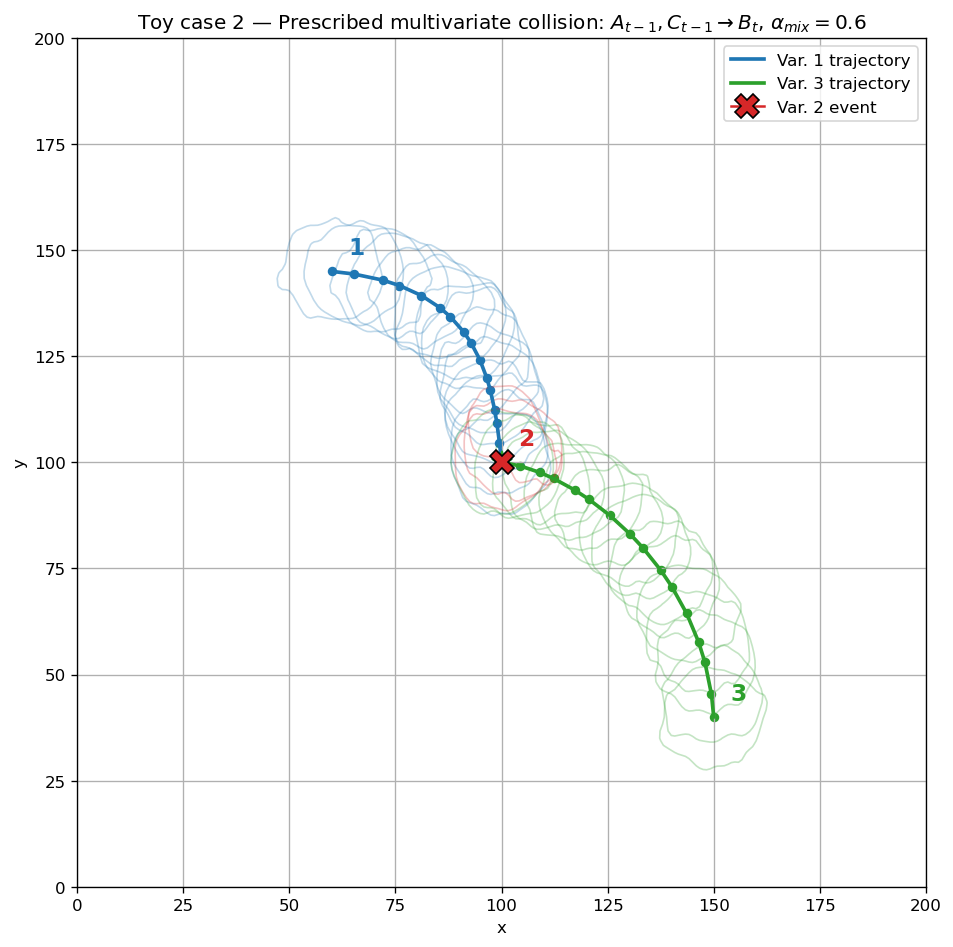

In [5]:
def plot_multivariate_truth(case, n_show=16, level=0.5):
    A = case["A"]
    B = case["B"]
    C = case["C"]
    centers_A = case["centers_A"]
    centers_C = case["centers_C"]
    event_y, event_x = case["event"]
    xs = case["xs"]
    ys = case["ys"]
    T = case["T"]

    fig, ax = plt.subplots(figsize=(10.5, 8))

    plot_idx = np.linspace(0, T - 1, n_show, dtype=int)
    plot_idx = np.unique(plot_idx)

    for t in plot_idx:
        ax.contour(xs, ys, A[t], levels=[level], colors=["tab:blue"], linewidths=1.0, alpha=0.28)
        ax.contour(xs, ys, B[t], levels=[level], colors=["tab:red"], linewidths=1.0, alpha=0.28)
        ax.contour(xs, ys, C[t], levels=[level], colors=["tab:green"], linewidths=1.0, alpha=0.28)

    ax.plot(centers_A[plot_idx, 1], centers_A[plot_idx, 0], "-", color="tab:blue", lw=2.2, label="Var. 1 trajectory")
    ax.scatter(centers_A[plot_idx, 1], centers_A[plot_idx, 0], s=22, color="tab:blue")

    ax.plot(centers_C[plot_idx, 1], centers_C[plot_idx, 0], "-", color="tab:green", lw=2.2, label="Var. 3 trajectory")
    ax.scatter(centers_C[plot_idx, 1], centers_C[plot_idx, 0], s=22, color="tab:green")

    ax.plot(event_x, event_y, marker="X", markersize=14, color="tab:red",
            markeredgecolor="black", zorder=10, label="Var. 2 event")

    ax.plot(centers_A[-1, 1], centers_A[-1, 0], marker="*", markersize=13, color="tab:blue")
    ax.plot(centers_C[-1, 1], centers_C[-1, 0], marker="*", markersize=13, color="tab:green")

    ax.text(centers_A[0, 1] + 4, centers_A[0, 0] + 4, "1", fontsize=14, fontweight="bold", color="tab:blue")
    ax.text(event_x + 4, event_y + 4, "2", fontsize=14, fontweight="bold", color="tab:red")
    ax.text(centers_C[0, 1] + 4, centers_C[0, 0] + 4, "3", fontsize=14, fontweight="bold", color="tab:green")

    ax.set_xlim(0, 200)
    ax.set_ylim(0, 200)
    ax.set_aspect("equal")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title(
        rf"Toy case 2 — Prescribed multivariate collision: $A_{{t-1}}, C_{{t-1}} \rightarrow B_t$, "
        rf"$\alpha_{{mix}}={case['alpha_mix']:.1f}$"
    )
    ax.legend(loc="upper right", frameon=True)
    plt.tight_layout()
    plt.show()

plot_multivariate_truth(case)

# Run single trajectory

In [12]:
def build_base_params_multivar():
    return dict(
        timeres="1d",
        spaceres=1,
        box_size=20,
        radius=2,
        starting_lat=None,
        starting_lon=None,
        timewindow="4d",
        child_of_interest=2,   # B
        n_steps_time=30,
        averaging_winners=True,
        snap_to_grid=False,
        montecarlo=True,
        beta_softmax=1.0,
        eps_dbscan=0.15,
        min_samples_dbscan=2,
        score_mode="mean",
        alpha=4.0,
        prefer_sign="both",
        verbose=False,
        winner_summary="mean",
        prob_rule="softmax",
        cd_method="granger",
        cd_kwargs=dict(
            lambda_a=0.5,
            l1_ratio=0.4,
            dependence_threshold=1e-7,
            max_iter=100000,
            fit_intercept=False,
            refit_ridge=False,
            ridge_alpha=1e-2,
        ),
    )

params_base = build_base_params_multivar()
params_base

{'timeres': '1d',
 'spaceres': 1,
 'box_size': 20,
 'radius': 2,
 'starting_lat': None,
 'starting_lon': None,
 'timewindow': '4d',
 'child_of_interest': 2,
 'n_steps_time': 30,
 'averaging_winners': True,
 'snap_to_grid': False,
 'montecarlo': True,
 'beta_softmax': 1.0,
 'eps_dbscan': 0.15,
 'min_samples_dbscan': 2,
 'score_mode': 'mean',
 'gamma': 0.5,
 'alpha': 4.0,
 'prefer_sign': 'both',
 'verbose': False,
 'winner_summary': 'mean',
 'prob_rule': 'softmax',
 'cd_method': 'granger',
 'cd_kwargs': {'lambda_a': 0.5,
  'l1_ratio': 0.4,
  'dependence_threshold': 1e-07,
  'max_iter': 100000,
  'fit_intercept': False,
  'refit_ridge': False,
  'ridge_alpha': 0.01}}

In [13]:
params_one = copy.deepcopy(params_base)
params_one["starting_lat"] = float(case["event"][0])
params_one["starting_lon"] = float(case["event"][1])

centers_one, parents_one, out_one = run_one_track(case["full_data_run"], params_one, case["date_end"])

print("trajectory length:", len(centers_one))
print("parents used:", parents_one)
print("unique parents:", np.unique(parents_one) if len(parents_one) else [])

trajectory length: 31
parents used: [2 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3]
unique parents: [2 3]


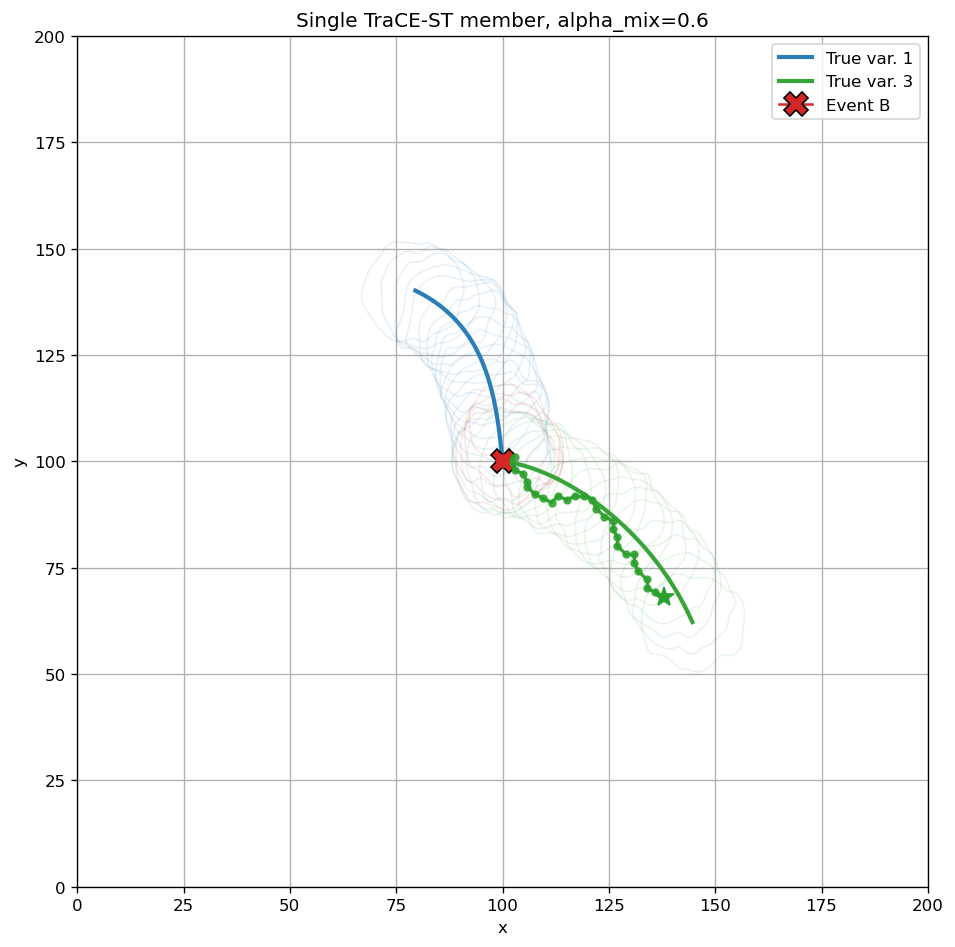

In [24]:
def plot_single_member(case, centers, parents, params, title=None):
    xs = case["xs"]
    ys = case["ys"]
    A = case["A"]
    B = case["B"]
    C = case["C"]
    centers_A = np.asarray(case["centers_A"], dtype=float)
    centers_C = np.asarray(case["centers_C"], dtype=float)
    event_y, event_x = case["event"]
    T = case["T"]

    n_back = int(params["n_steps_time"])
    target_len = n_back + 1

    # only the segment that is actually recoverable
    truth_A_cmp = centers_A[-target_len:]
    truth_C_cmp = centers_C[-target_len:]

    var_colors = {1: "tab:blue", 2: "tab:red", 3: "tab:green"}

    fig, ax = plt.subplots(figsize=(10.5, 8))

    # contours ONLY over comparable time range
    plot_idx = np.linspace(T - target_len, T - 1, 16, dtype=int)
    plot_idx = np.unique(plot_idx)

    for t in plot_idx:
        ax.contour(xs, ys, A[t], levels=[0.5], colors=["tab:blue"], linewidths=1.0, alpha=0.10)
        ax.contour(xs, ys, B[t], levels=[0.5], colors=["tab:red"], linewidths=1.0, alpha=0.10)
        ax.contour(xs, ys, C[t], levels=[0.5], colors=["tab:green"], linewidths=1.0, alpha=0.10)

    # true trajectories (ONLY comparable segment)
    ax.plot(
        truth_A_cmp[:, 1], truth_A_cmp[:, 0],
        "-", color="tab:blue", lw=2.5, alpha=0.95,
        label="True var. 1"
    )
    ax.plot(
        truth_C_cmp[:, 1], truth_C_cmp[:, 0],
        "-", color="tab:green", lw=2.5, alpha=0.95,
        label="True var. 3"
    )

    # event
    ax.plot(
        event_x, event_y,
        marker="X", markersize=14,
        color="tab:red", markeredgecolor="black",
        label="Event B"
    )

    # modeled trajectory
    if len(centers) > 0:
        for i in range(len(centers) - 1):
            p = int(parents[i])
            ax.plot(
                centers[i:i+2, 1],
                centers[i:i+2, 0],
                "-",
                color=var_colors.get(p, "k"),
                linewidth=2.0,
                alpha=0.95,
            )

        for (yc, xc), p in zip(centers, parents):
            ax.plot(
                xc, yc,
                "o", ms=4,
                color=var_colors.get(int(p), "k"),
                alpha=0.80
            )

        ax.plot(
            centers[0, 1], centers[0, 0],
            "s", ms=7,
            color=var_colors.get(int(parents[0]), "k")
        )
        ax.plot(
            centers[-1, 1], centers[-1, 0],
            "*", ms=12,
            color=var_colors.get(int(parents[-1]), "k")
        )

    ax.set_xlim(0, 200)
    ax.set_ylim(0, 200)
    ax.set_aspect("equal")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title(title if title is not None else "Single TraCE-ST member")
    ax.legend(loc="upper right", frameon=True)

    plt.tight_layout()
    plt.show()

plot_single_member(
    case,
    centers_one,
    parents_one,
    params_one,
    title=f"Single TraCE-ST member, alpha_mix={case['alpha_mix']:.1f}"
)

# Run ensemble

In [102]:
def run_ensemble(case, base_params, M=30, seed=123):
    rng_local = np.random.default_rng(seed)

    members = []
    for m in range(M):
        p = copy.deepcopy(base_params)
        p["starting_lat"] = float(case["event"][0])
        p["starting_lon"] = float(case["event"][1])

        # keep everything fixed except the internal stochastic movement realization
        # by reseeding numpy before each run
        np.random.seed(int(rng_local.integers(0, 2_000_000_000)))

        t0 = time.perf_counter()
        # try:
        centers, parents, out = run_one_track(case["full_data_run"], p, case["date_end"])
        ok = True
        err = ""
        # except Exception as e:
        #     centers = np.empty((0, 2), dtype=float)
        #     parents = np.empty((0,), dtype=int)
        #     out = None
        #     ok = False
        #     err = str(e)

        members.append({
            "member_id": m,
            "ok": ok,
            "error": err,
            "elapsed_sec": time.perf_counter() - t0,
            "centers": np.asarray(centers, dtype=float),
            "parents": np.asarray(parents, dtype=int),
            "out": out,
        })

    return {"members": members, "params": copy.deepcopy(base_params), "M": M}

In [103]:
def _accumulate_density_box(density, xs, ys, centers, box_size):
    """
    Accumulate density using the full box footprint at each trajectory step,
    not just the trajectory center.
    """
    centers = np.asarray(centers, dtype=float)
    if len(centers) == 0:
        return density

    half = box_size / 2.0

    for yc, xc in centers:
        x0 = xc - half
        x1 = xc + half
        y0 = yc - half
        y1 = yc + half

        xmask = (xs >= x0) & (xs <= x1)
        ymask = (ys >= y0) & (ys <= y1)

        if np.any(xmask) and np.any(ymask):
            density[np.ix_(ymask, xmask)] += 1.0

    return density


def summarize_ensemble(case, ensemble_out, params):
    xs = case["xs"]
    ys = case["ys"]
    shape2d = (len(ys), len(xs))
    box_size = float(params["box_size"])

    density_by_parent = {
        1: np.zeros(shape2d, dtype=float),
        2: np.zeros(shape2d, dtype=float),
        3: np.zeros(shape2d, dtype=float),
    }

    initial_parent_counts = {1: 0, 2: 0, 3: 0}
    end_parent_counts = {1: 0, 2: 0, 3: 0}
    step_parent_counts = {1: 0, 2: 0, 3: 0}
    n_ok = 0

    rows = []

    for member in ensemble_out["members"]:
        if not member["ok"]:
            rows.append({
                "member_id": member["member_id"],
                "ok": 0,
                "n_steps": 0,
                "initial_parent": np.nan,
                "end_parent": np.nan,
                "frac_parent1": np.nan,
                "frac_parent2": np.nan,
                "frac_parent3": np.nan,
            })
            continue

        centers = np.asarray(member["centers"], dtype=float)
        parents = np.asarray(member["parents"], dtype=int)

        if len(centers) == 0 or len(parents) == 0:
            rows.append({
                "member_id": member["member_id"],
                "ok": 0,
                "n_steps": 0,
                "initial_parent": np.nan,
                "end_parent": np.nan,
                "frac_parent1": np.nan,
                "frac_parent2": np.nan,
                "frac_parent3": np.nan,
            })
            continue

        n_ok += 1

        if len(parents) >= 2:
            initial_parent = int(parents[1])
        else:
            initial_parent = np.nan
        end_parent = int(parents[-1])

        if initial_parent in initial_parent_counts:
            initial_parent_counts[initial_parent] += 1

        if end_parent in end_parent_counts:
            end_parent_counts[end_parent] += 1

        for p in [1, 2, 3]:
            mask = (parents == p)
            step_parent_counts[p] += int(mask.sum())
            density_by_parent[p] = _accumulate_density_box(
                density_by_parent[p],
                xs,
                ys,
                centers[mask],
                box_size=box_size,
            )

        rows.append({
            "member_id": member["member_id"],
            "ok": 1,
            "n_steps": len(parents),
            "initial_parent": initial_parent,
            "end_parent": end_parent,
            "frac_parent1": float(np.mean(parents == 1)),
            "frac_parent2": float(np.mean(parents == 2)),
            "frac_parent3": float(np.mean(parents == 3)),
        })

    df_members = pd.DataFrame(rows)

    total_initial = sum(initial_parent_counts.values())
    total_end = sum(end_parent_counts.values())
    total_steps = sum(step_parent_counts.values())

    initial_parent_frac = {
        p: (initial_parent_counts[p] / total_initial if total_initial > 0 else np.nan)
        for p in [1, 2, 3]
    }
    end_parent_frac = {
        p: (end_parent_counts[p] / total_end if total_end > 0 else np.nan)
        for p in [1, 2, 3]
    }
    step_parent_frac = {
        p: (step_parent_counts[p] / total_steps if total_steps > 0 else np.nan)
        for p in [1, 2, 3]
    }

    density_integral = {
        p: float(np.nansum(density_by_parent[p]))
        for p in [1, 2, 3]
    }
    total_density_integral = float(sum(density_integral.values()))
    density_integral_frac = {
        p: (density_integral[p] / total_density_integral if total_density_integral > 0 else np.nan)
        for p in [1, 2, 3]
    }

    frac_mean = {}
    frac_std = {}
    for p in [1, 2, 3]:
        col = f"frac_parent{p}"
        valid = df_members.loc[df_members["ok"] == 1, col].astype(float)
        frac_mean[p] = float(valid.mean()) if len(valid) > 0 else np.nan
        frac_std[p] = float(valid.std(ddof=0)) if len(valid) > 0 else np.nan

    summary = {
        "n_members": len(ensemble_out["members"]),
        "n_ok": n_ok,
        "initial_parent_counts": initial_parent_counts,
        "initial_parent_frac": initial_parent_frac,
        "end_parent_counts": end_parent_counts,
        "end_parent_frac": end_parent_frac,
        "step_parent_counts": step_parent_counts,
        "step_parent_frac": step_parent_frac,
        "density_by_parent": density_by_parent,
        "density_integral": density_integral,
        "density_integral_total": total_density_integral,
        "density_integral_frac": density_integral_frac,
        "member_frac_mean": frac_mean,
        "member_frac_std": frac_std,
        "df_members": df_members,
    }
    return summary

In [91]:
# ensemble_out = run_ensemble(case, params_base, M=30, seed=11)
summary = summarize_ensemble(case, ensemble_out,params_base)

def print_ensemble_summary(summary):
    print("=== Ensemble summary ===")
    print(f"M total: {summary['n_members']}")
    print(f"M ok:    {summary['n_ok']}")
    print(f"M fail:  {summary['n_members'] - summary['n_ok']}")
    print()

    print("Initial parent counts:")
    print(summary["initial_parent_counts"])
    print("Initial parent fractions:")
    print(summary["initial_parent_frac"])
    print()

    print("End parent counts:")
    print(summary["end_parent_counts"])
    print("End parent fractions:")
    print(summary["end_parent_frac"])
    print()

    print("Step parent counts:")
    print(summary["step_parent_counts"])
    print("Step parent fractions:")
    print(summary["step_parent_frac"])
    print()

    print("Integrated density totals:")
    print(summary["density_integral"])
    print(f"Integrated density total: {summary['density_integral_total']:.3f}")
    print("Integrated density fractions:")
    print(summary["density_integral_frac"])
    print()

    print("Member-mean parent fractions:")
    print(summary["member_frac_mean"])
    print("Member-std parent fractions:")
    print(summary["member_frac_std"])

In [92]:
print_ensemble_summary(summary)

=== Ensemble summary ===
M total: 30
M ok:    30
M fail:  0

Initial parent counts:
{1: 17, 2: 6, 3: 7}
Initial parent fractions:
{1: 0.5666666666666667, 2: 0.2, 3: 0.23333333333333334}

End parent counts:
{1: 21, 2: 0, 3: 9}
End parent fractions:
{1: 0.7, 2: 0.0, 3: 0.3}

Step parent counts:
{1: 626, 2: 36, 3: 268}
Step parent fractions:
{1: 0.6731182795698925, 2: 0.03870967741935484, 3: 0.28817204301075267}

Integrated density totals:
{1: 180747.0, 2: 11502.0, 3: 77462.0}
Integrated density total: 269711.000
Integrated density fractions:
{1: 0.6701506427249908, 2: 0.042645646636585086, 3: 0.2872037106384241}

Member-mean parent fractions:
{1: 0.6731182795698925, 2: 0.038709677419354833, 3: 0.28817204301075267}
Member-std parent fractions:
{1: 0.42938649240122917, 2: 0.012903225806451613, 3: 0.4288368326306592}


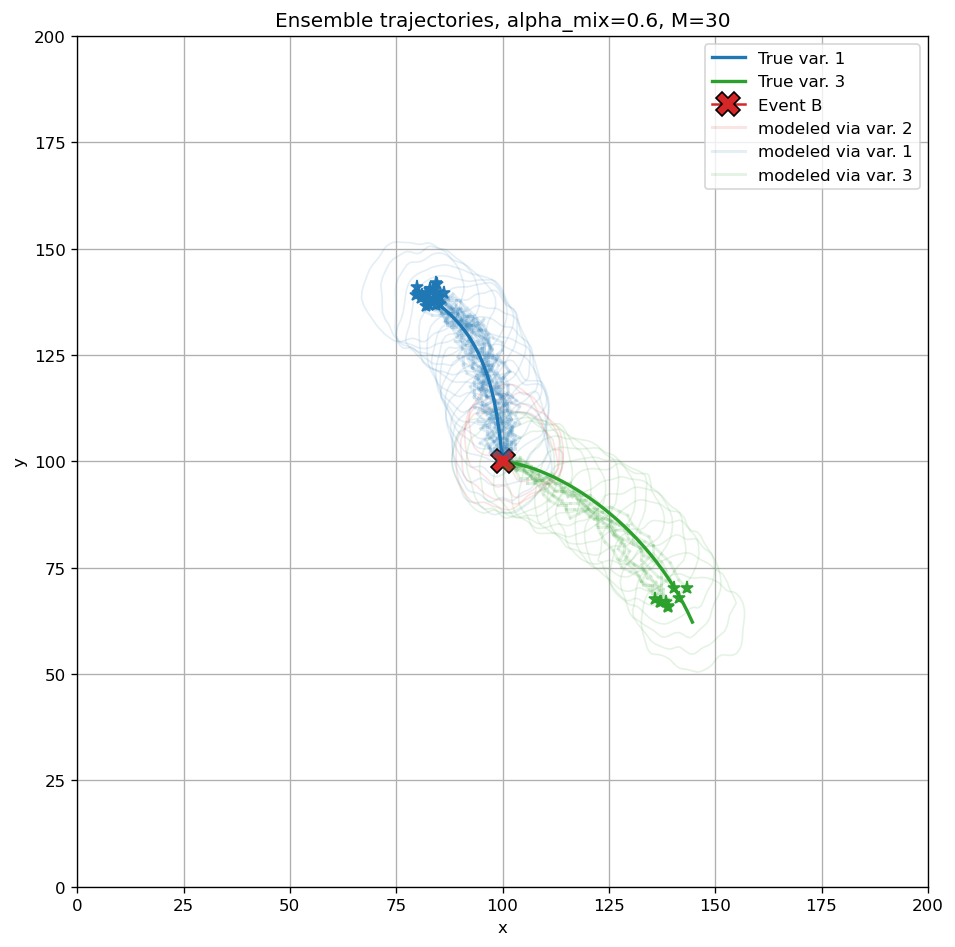

In [93]:
def plot_ensemble_members(case, ensemble_out, params, alpha_members=0.12):
    xs = case["xs"]
    ys = case["ys"]
    A = case["A"]
    B = case["B"]
    C = case["C"]
    centers_A = np.asarray(case["centers_A"], dtype=float)
    centers_C = np.asarray(case["centers_C"], dtype=float)
    event_y, event_x = case["event"]
    T = case["T"]

    n_back = int(params["n_steps_time"])
    target_len = n_back + 1

    truth_A_cmp = centers_A[-target_len:]
    truth_C_cmp = centers_C[-target_len:]

    var_colors = {1: "tab:blue", 2: "tab:red", 3: "tab:green"}

    fig, ax = plt.subplots(figsize=(10.5, 8))

    # contours only over comparable time range
    plot_idx = np.linspace(T - target_len, T - 1, 16, dtype=int)
    plot_idx = np.unique(plot_idx)

    for t in plot_idx:
        ax.contour(xs, ys, A[t], levels=[0.5], colors=["tab:blue"], linewidths=1.0, alpha=0.12)
        ax.contour(xs, ys, B[t], levels=[0.5], colors=["tab:red"], linewidths=1.0, alpha=0.12)
        ax.contour(xs, ys, C[t], levels=[0.5], colors=["tab:green"], linewidths=1.0, alpha=0.12)

    # true trajectories only over comparable segment
    ax.plot(
        truth_A_cmp[:, 1], truth_A_cmp[:, 0],
        "-", color="tab:blue", lw=2.0, label="True var. 1"
    )
    ax.plot(
        truth_C_cmp[:, 1], truth_C_cmp[:, 0],
        "-", color="tab:green", lw=2.0, label="True var. 3"
    )

    ax.plot(
        event_x, event_y,
        marker="X", markersize=14,
        color="tab:red", markeredgecolor="black",
        label="Event B"
    )

    shown = set()
    for member in ensemble_out["members"]:
        if not member["ok"]:
            continue

        centers = np.asarray(member["centers"], dtype=float)
        parents = np.asarray(member["parents"], dtype=int)

        if len(centers) == 0:
            continue

        for i in range(len(centers) - 1):
            p = int(parents[i])
            label = f"modeled via var. {p}" if p not in shown else None
            ax.plot(
                centers[i:i+2, 1],
                centers[i:i+2, 0],
                "-",
                color=var_colors.get(p, "k"),
                lw=1.8,
                alpha=alpha_members,
                label=label,
            )
            shown.add(p)

        p0 = int(parents[0])
        p1 = int(parents[-1])

        ax.plot(
            centers[0, 1], centers[0, 0],
            "s", ms=5,
            color=var_colors.get(p0, "k"),
            alpha=0.85
        )
        ax.plot(
            centers[-1, 1], centers[-1, 0],
            "*", ms=8,
            color=var_colors.get(p1, "k"),
            alpha=0.95
        )

    ax.set_xlim(0, 200)
    ax.set_ylim(0, 200)
    ax.set_aspect("equal")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title(
        f"Ensemble trajectories, alpha_mix={case['alpha_mix']:.1f}, "
        f"M={ensemble_out['M']}"
    )
    ax.legend(loc="upper right", frameon=True)
    plt.tight_layout()
    plt.show()

plot_ensemble_members(case, ensemble_out, params_base)

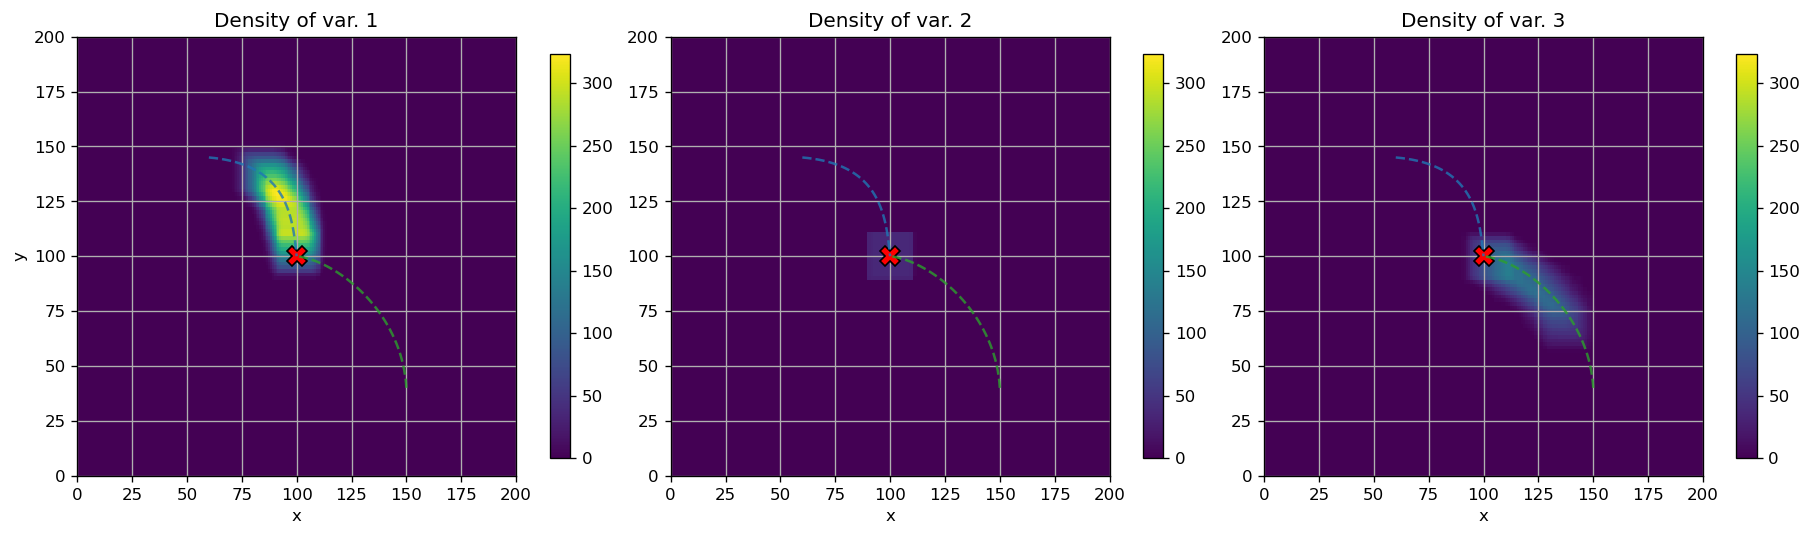

In [94]:
def plot_parent_densities(case, summary):
    xs = case["xs"]
    ys = case["ys"]
    event_y, event_x = case["event"]
    centers_A = case["centers_A"]
    centers_C = case["centers_C"]

    dens1 = summary["density_by_parent"][1]
    dens2 = summary["density_by_parent"][2]
    dens3 = summary["density_by_parent"][3]

    vmax = max(float(np.nanmax(dens1)), float(np.nanmax(dens2)), float(np.nanmax(dens3)), 1.0)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.8), constrained_layout=True)

    panels = [
        (1, dens1, "Density of var. 1"),
        (2, dens2, "Density of var. 2"),
        (3, dens3, "Density of var. 3"),
    ]

    for ax, (p, dens, title) in zip(axes, panels):
        im = ax.pcolormesh(xs, ys, dens, shading="auto", vmin=0, vmax=vmax)
        ax.plot(event_x, event_y, "X", ms=12, color="red", markeredgecolor="black")
        ax.plot(centers_A[:, 1], centers_A[:, 0], "--", color="tab:blue", lw=1.5, alpha=0.8)
        ax.plot(centers_C[:, 1], centers_C[:, 0], "--", color="tab:green", lw=1.5, alpha=0.8)
        ax.set_aspect("equal")
        ax.set_xlim(0, 200)
        ax.set_ylim(0, 200)
        ax.set_title(title)
        ax.set_xlabel("x")
        if ax is axes[0]:
            ax.set_ylabel("y")
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    plt.show()

plot_parent_densities(case, summary)

In [95]:
def summarize_against_truth(case, summary):
    target = case["target_parent_fractions"]

    row = {
        "alpha_mix": case["alpha_mix"],

        "target_var1": target[1],
        "target_var3": target[3],

        "initial_count_var1": summary["initial_parent_counts"][1],
        "initial_count_var2": summary["initial_parent_counts"][2],
        "initial_count_var3": summary["initial_parent_counts"][3],

        "initial_frac_var1": summary["initial_parent_frac"][1],
        "initial_frac_var2": summary["initial_parent_frac"][2],
        "initial_frac_var3": summary["initial_parent_frac"][3],

        "end_count_var1": summary["end_parent_counts"][1],
        "end_count_var2": summary["end_parent_counts"][2],
        "end_count_var3": summary["end_parent_counts"][3],

        "end_frac_var1": summary["end_parent_frac"][1],
        "end_frac_var2": summary["end_parent_frac"][2],
        "end_frac_var3": summary["end_parent_frac"][3],

        "step_count_var1": summary["step_parent_counts"][1],
        "step_count_var2": summary["step_parent_counts"][2],
        "step_count_var3": summary["step_parent_counts"][3],

        "step_frac_var1": summary["step_parent_frac"][1],
        "step_frac_var2": summary["step_parent_frac"][2],
        "step_frac_var3": summary["step_parent_frac"][3],

        "density_integral_var1": summary["density_integral"][1],
        "density_integral_var2": summary["density_integral"][2],
        "density_integral_var3": summary["density_integral"][3],

        "density_frac_var1": summary["density_integral_frac"][1],
        "density_frac_var2": summary["density_integral_frac"][2],
        "density_frac_var3": summary["density_integral_frac"][3],

        "member_mean_frac_var1": summary["member_frac_mean"][1],
        "member_mean_frac_var2": summary["member_frac_mean"][2],
        "member_mean_frac_var3": summary["member_frac_mean"][3],

        "member_std_frac_var1": summary["member_frac_std"][1],
        "member_std_frac_var2": summary["member_frac_std"][2],
        "member_std_frac_var3": summary["member_frac_std"][3],

        "abs_err_initial_var1": abs(summary["initial_parent_frac"][1] - target[1]),
        "abs_err_initial_var3": abs(summary["initial_parent_frac"][3] - target[3]),

        "abs_err_end_var1": abs(summary["end_parent_frac"][1] - target[1]),
        "abs_err_end_var3": abs(summary["end_parent_frac"][3] - target[3]),

        "abs_err_step_var1": abs(summary["step_parent_frac"][1] - target[1]),
        "abs_err_step_var3": abs(summary["step_parent_frac"][3] - target[3]),

        "abs_err_density_var1": abs(summary["density_integral_frac"][1] - target[1]),
        "abs_err_density_var3": abs(summary["density_integral_frac"][3] - target[3]),

        "mae_initial": np.nanmean([
            abs(summary["initial_parent_frac"][1] - target[1]),
            abs(summary["initial_parent_frac"][3] - target[3]),
        ]),
        "mae_end": np.nanmean([
            abs(summary["end_parent_frac"][1] - target[1]),
            abs(summary["end_parent_frac"][3] - target[3]),
        ]),
        "mae_step": np.nanmean([
            abs(summary["step_parent_frac"][1] - target[1]),
            abs(summary["step_parent_frac"][3] - target[3]),
        ]),
        "mae_density": np.nanmean([
            abs(summary["density_integral_frac"][1] - target[1]),
            abs(summary["density_integral_frac"][3] - target[3]),
        ]),

        "n_ok": summary["n_ok"],
        "M": summary["n_members"],
        "ok_frac": summary["n_ok"] / summary["n_members"] if summary["n_members"] > 0 else np.nan,
    }

    return pd.DataFrame([row])

summarize_against_truth(case, summary)

,alpha_mix,target_var1,target_var3,initial_count_var1,initial_count_var2,initial_count_var3,initial_frac_var1,initial_frac_var2,initial_frac_var3,end_count_var1,...,abs_err_step_var3,abs_err_density_var1,abs_err_density_var3,mae_initial,mae_end,mae_step,mae_density,n_ok,M,ok_frac
0,0.6,0.6,0.4,17,6,7,0.566667,0.2,0.233333,21,...,0.111828,0.070151,0.112796,0.1,0.1,0.092473,0.091473,30,30,1.0


# Hyperparameter search

In [104]:
def _member_geometry_stats(centers, parents):
    centers = np.asarray(centers, dtype=float)
    parents = np.asarray(parents, dtype=int)

    if len(centers) == 0 or len(parents) == 0:
        return dict(
            n_steps=0,
            path_length=np.nan,
            net_displacement=np.nan,
            mean_step=np.nan,
            stagnant_frac=np.nan,
            first_step_parent=np.nan,   # first non-trivial decision = parents[1]
            end_parent=np.nan,
            frac_parent1=np.nan,
            frac_parent2=np.nan,
            frac_parent3=np.nan,
            frac_nontrivial=np.nan,
            any_nontrivial=0,
            ended_nontrivial=0,
            unique_nontrivial_count=0,
            uses_parent1=0,
            uses_parent3=0,
            uses_both_nontrivial=0,
        )

    if len(centers) >= 2:
        diffs = np.diff(centers, axis=0)
        steps = np.sqrt(np.sum(diffs**2, axis=1))
        path_length = float(np.sum(steps))
        net_displacement = float(np.sqrt(np.sum((centers[-1] - centers[0]) ** 2)))
        mean_step = float(np.mean(steps))
        stagnant_frac = float(np.mean(steps < 1e-6))
    else:
        path_length = 0.0
        net_displacement = 0.0
        mean_step = 0.0
        stagnant_frac = 1.0

    first_step_parent = int(parents[1]) if len(parents) >= 2 else np.nan
    end_parent = int(parents[-1])

    nontrivial = parents[1:] if len(parents) >= 2 else np.array([], dtype=int)
    nontrivial_mask = np.isin(nontrivial, [1, 3])

    unique_nontrivial = np.unique(nontrivial[nontrivial_mask]) if len(nontrivial) else np.array([], dtype=int)

    return dict(
        n_steps=int(len(parents)),
        path_length=path_length,
        net_displacement=net_displacement,
        mean_step=mean_step,
        stagnant_frac=stagnant_frac,
        first_step_parent=first_step_parent,
        end_parent=end_parent,
        frac_parent1=float(np.mean(parents == 1)),
        frac_parent2=float(np.mean(parents == 2)),
        frac_parent3=float(np.mean(parents == 3)),
        frac_nontrivial=float(np.mean(np.isin(parents, [1, 3]))),
        any_nontrivial=int(np.any(np.isin(nontrivial, [1, 3]))),
        ended_nontrivial=int(end_parent in [1, 3]),
        unique_nontrivial_count=int(len(unique_nontrivial)),
        uses_parent1=int(np.any(parents == 1)),
        uses_parent3=int(np.any(parents == 3)),
        uses_both_nontrivial=int((1 in unique_nontrivial) and (3 in unique_nontrivial)),
    )


def summarize_ensemble(case, ensemble_out, params):
    xs = case["xs"]
    ys = case["ys"]
    shape2d = (len(ys), len(xs))
    box_size = float(params["box_size"])

    density_by_parent = {
        1: np.zeros(shape2d, dtype=float),
        2: np.zeros(shape2d, dtype=float),
        3: np.zeros(shape2d, dtype=float),
    }

    initial_parent_counts = {1: 0, 2: 0, 3: 0}
    end_parent_counts = {1: 0, 2: 0, 3: 0}
    step_parent_counts = {1: 0, 2: 0, 3: 0}
    n_ok = 0

    rows = []

    for member in ensemble_out["members"]:
        member_id = member["member_id"]

        if not member["ok"]:
            rows.append({
                "member_id": member_id,
                "ok": 0,
                "error": member.get("error", ""),
                **_member_geometry_stats([], []),
            })
            continue

        centers = np.asarray(member["centers"], dtype=float)
        parents = np.asarray(member["parents"], dtype=int)

        if len(centers) == 0 or len(parents) == 0:
            rows.append({
                "member_id": member_id,
                "ok": 0,
                "error": member.get("error", ""),
                **_member_geometry_stats([], []),
            })
            continue

        n_ok += 1

        stats = _member_geometry_stats(centers, parents)

        initial_parent = stats["first_step_parent"]
        end_parent = stats["end_parent"]

        if initial_parent in initial_parent_counts:
            initial_parent_counts[initial_parent] += 1
        if end_parent in end_parent_counts:
            end_parent_counts[end_parent] += 1

        for p in [1, 2, 3]:
            mask = (parents == p)
            step_parent_counts[p] += int(mask.sum())
            density_by_parent[p] = _accumulate_density_box(
                density_by_parent[p],
                xs,
                ys,
                centers[mask],
                box_size=box_size,
            )

        rows.append({
            "member_id": member_id,
            "ok": 1,
            "error": "",
            **stats,
        })

    df_members = pd.DataFrame(rows)

    total_initial = sum(initial_parent_counts.values())
    total_end = sum(end_parent_counts.values())
    total_steps = sum(step_parent_counts.values())

    initial_parent_frac = {
        p: (initial_parent_counts[p] / total_initial if total_initial > 0 else np.nan)
        for p in [1, 2, 3]
    }
    end_parent_frac = {
        p: (end_parent_counts[p] / total_end if total_end > 0 else np.nan)
        for p in [1, 2, 3]
    }
    step_parent_frac = {
        p: (step_parent_counts[p] / total_steps if total_steps > 0 else np.nan)
        for p in [1, 2, 3]
    }

    density_integral = {
        p: float(np.nansum(density_by_parent[p]))
        for p in [1, 2, 3]
    }
    density_integral_total = float(sum(density_integral.values()))
    density_integral_frac = {
        p: (density_integral[p] / density_integral_total if density_integral_total > 0 else np.nan)
        for p in [1, 2, 3]
    }

    valid_members = df_members[df_members["ok"] == 1].copy()

    def _safe_mean(col):
        return float(valid_members[col].mean()) if len(valid_members) else np.nan

    def _safe_std(col):
        return float(valid_members[col].std(ddof=0)) if len(valid_members) else np.nan

    def _safe_q(col, q):
        return float(valid_members[col].quantile(q)) if len(valid_members) else np.nan

    member_frac_mean = {
        p: _safe_mean(f"frac_parent{p}") for p in [1, 2, 3]
    }
    member_frac_std = {
        p: _safe_std(f"frac_parent{p}") for p in [1, 2, 3]
    }

    validity_metrics = {
        "ok_frac": (n_ok / len(ensemble_out["members"])) if len(ensemble_out["members"]) else np.nan,

        "mean_n_steps": _safe_mean("n_steps"),
        "median_n_steps": _safe_q("n_steps", 0.5),
        "q25_n_steps": _safe_q("n_steps", 0.25),
        "min_n_steps": float(valid_members["n_steps"].min()) if len(valid_members) else np.nan,

        "mean_path_length": _safe_mean("path_length"),
        "median_path_length": _safe_q("path_length", 0.5),
        "mean_net_displacement": _safe_mean("net_displacement"),
        "median_net_displacement": _safe_q("net_displacement", 0.5),
        "mean_mean_step": _safe_mean("mean_step"),

        "mean_stagnant_frac": _safe_mean("stagnant_frac"),
        "median_stagnant_frac": _safe_q("stagnant_frac", 0.5),

        "frac_members_any_nontrivial": _safe_mean("any_nontrivial"),
        "frac_members_end_nontrivial": _safe_mean("ended_nontrivial"),
        "frac_members_use_parent1": _safe_mean("uses_parent1"),
        "frac_members_use_parent3": _safe_mean("uses_parent3"),
        "frac_members_use_both_nontrivial": _safe_mean("uses_both_nontrivial"),

        "mean_unique_nontrivial_count": _safe_mean("unique_nontrivial_count"),

        "mean_frac_parent1": _safe_mean("frac_parent1"),
        "mean_frac_parent2": _safe_mean("frac_parent2"),
        "mean_frac_parent3": _safe_mean("frac_parent3"),
    }

    summary = {
        "n_members": len(ensemble_out["members"]),
        "n_ok": n_ok,

        "initial_parent_counts": initial_parent_counts,
        "initial_parent_frac": initial_parent_frac,

        "end_parent_counts": end_parent_counts,
        "end_parent_frac": end_parent_frac,

        "step_parent_counts": step_parent_counts,
        "step_parent_frac": step_parent_frac,

        "density_by_parent": density_by_parent,
        "density_integral": density_integral,
        "density_integral_total": density_integral_total,
        "density_integral_frac": density_integral_frac,

        "member_frac_mean": member_frac_mean,
        "member_frac_std": member_frac_std,

        "validity_metrics": validity_metrics,
        "df_members": df_members,
    }
    return summary

In [105]:
def summarize_against_truth(case, summary):
    target = case["target_parent_fractions"]
    vm = summary["validity_metrics"]

    row = {
        "alpha_mix": case["alpha_mix"],

        "target_var1": target[1],
        "target_var3": target[3],

        "initial_count_var1": summary["initial_parent_counts"][1],
        "initial_count_var2": summary["initial_parent_counts"][2],
        "initial_count_var3": summary["initial_parent_counts"][3],

        "initial_frac_var1": summary["initial_parent_frac"][1],
        "initial_frac_var2": summary["initial_parent_frac"][2],
        "initial_frac_var3": summary["initial_parent_frac"][3],

        "end_count_var1": summary["end_parent_counts"][1],
        "end_count_var2": summary["end_parent_counts"][2],
        "end_count_var3": summary["end_parent_counts"][3],

        "end_frac_var1": summary["end_parent_frac"][1],
        "end_frac_var2": summary["end_parent_frac"][2],
        "end_frac_var3": summary["end_parent_frac"][3],

        "step_count_var1": summary["step_parent_counts"][1],
        "step_count_var2": summary["step_parent_counts"][2],
        "step_count_var3": summary["step_parent_counts"][3],

        "step_frac_var1": summary["step_parent_frac"][1],
        "step_frac_var2": summary["step_parent_frac"][2],
        "step_frac_var3": summary["step_parent_frac"][3],

        "density_integral_var1": summary["density_integral"][1],
        "density_integral_var2": summary["density_integral"][2],
        "density_integral_var3": summary["density_integral"][3],

        "density_frac_var1": summary["density_integral_frac"][1],
        "density_frac_var2": summary["density_integral_frac"][2],
        "density_frac_var3": summary["density_integral_frac"][3],

        "member_mean_frac_var1": summary["member_frac_mean"][1],
        "member_mean_frac_var2": summary["member_frac_mean"][2],
        "member_mean_frac_var3": summary["member_frac_mean"][3],

        "member_std_frac_var1": summary["member_frac_std"][1],
        "member_std_frac_var2": summary["member_frac_std"][2],
        "member_std_frac_var3": summary["member_frac_std"][3],

        "abs_err_initial_var1": abs(summary["initial_parent_frac"][1] - target[1]),
        "abs_err_initial_var3": abs(summary["initial_parent_frac"][3] - target[3]),

        "abs_err_end_var1": abs(summary["end_parent_frac"][1] - target[1]),
        "abs_err_end_var3": abs(summary["end_parent_frac"][3] - target[3]),

        "abs_err_step_var1": abs(summary["step_parent_frac"][1] - target[1]),
        "abs_err_step_var3": abs(summary["step_parent_frac"][3] - target[3]),

        "abs_err_density_var1": abs(summary["density_integral_frac"][1] - target[1]),
        "abs_err_density_var3": abs(summary["density_integral_frac"][3] - target[3]),

        "mae_initial": np.nanmean([
            abs(summary["initial_parent_frac"][1] - target[1]),
            abs(summary["initial_parent_frac"][3] - target[3]),
        ]),
        "mae_end": np.nanmean([
            abs(summary["end_parent_frac"][1] - target[1]),
            abs(summary["end_parent_frac"][3] - target[3]),
        ]),
        "mae_step": np.nanmean([
            abs(summary["step_parent_frac"][1] - target[1]),
            abs(summary["step_parent_frac"][3] - target[3]),
        ]),
        "mae_density": np.nanmean([
            abs(summary["density_integral_frac"][1] - target[1]),
            abs(summary["density_integral_frac"][3] - target[3]),
        ]),

        "n_ok": summary["n_ok"],
        "M": summary["n_members"],

        "ok_frac": vm["ok_frac"],
        "mean_n_steps": vm["mean_n_steps"],
        "q25_n_steps": vm["q25_n_steps"],
        "min_n_steps": vm["min_n_steps"],
        "mean_path_length": vm["mean_path_length"],
        "mean_net_displacement": vm["mean_net_displacement"],
        "mean_mean_step": vm["mean_mean_step"],
        "mean_stagnant_frac": vm["mean_stagnant_frac"],
        "frac_members_any_nontrivial": vm["frac_members_any_nontrivial"],
        "frac_members_end_nontrivial": vm["frac_members_end_nontrivial"],
        "frac_members_use_parent1": vm["frac_members_use_parent1"],
        "frac_members_use_parent3": vm["frac_members_use_parent3"],
        "frac_members_use_both_nontrivial": vm["frac_members_use_both_nontrivial"],
        "mean_unique_nontrivial_count": vm["mean_unique_nontrivial_count"],
    }

    return pd.DataFrame([row])

In [106]:
ALPHA_MIX_GRID = [0.2, 0.4, 0.6, 0.8]

SEARCH_SPACE_SHARED = dict(
    timewindow=["2d", "3d", "4d"],
    box_size=[15, 20, 25, 30],
    radius=[2, 3],
    eps_dbscan=[0.05, 0.10, 0.15, 0.20, 0.25],
    min_samples_dbscan=[2],
    score_mode=["mean", "sum"],
    winner_summary=["mean"],
    alpha=[0.0, 0.5, 1.0, 2.0, 4.0, 8.0, 16.0, 32.0, 64.0],
    prefer_sign=["both"],
)

SEARCH_SPACE_PROB = dict(
    prob_rule=["linear", "softmax"],
    beta_softmax=[0.0, 0.5, 1.0, 2.0, 4.0, 8.0, 16.0, 32.0, 64.0],
)

SEARCH_SPACE_GRANGER = dict(
    lambda_a=lambda rng: float(10 ** rng.uniform(-3.0, -0.5)),
    l1_ratio=lambda rng: float(10 ** rng.uniform(-4.0, 0.0)),
    dependence_threshold=[1e-7],
    max_iter=[100000],
    fit_intercept=[False],
    refit_ridge=[False],
    ridge_alpha=[1e-2],
)


def _draw_from_space(rng, x):
    if callable(x):
        return x(rng)
    v = rng.choice(x)
    if isinstance(v, np.str_):
        return str(v)
    if isinstance(v, np.generic):
        return v.item()
    return v


def sample_multivar_trial(rng):
    trial = {}

    for k, v in SEARCH_SPACE_SHARED.items():
        trial[k] = _draw_from_space(rng, v)

    for k, v in SEARCH_SPACE_PROB.items():
        trial[k] = _draw_from_space(rng, v)

    for k, v in SEARCH_SPACE_GRANGER.items():
        trial[k] = _draw_from_space(rng, v)

    return trial

In [107]:
def build_params_from_trial_multivar(trial):
    p = build_base_params_multivar()

    for k in [
        "timewindow",
        "box_size",
        "radius",
        "eps_dbscan",
        "min_samples_dbscan",
        "score_mode",
        "winner_summary",
        "alpha",
        "prefer_sign",
        "prob_rule",
        "beta_softmax",
    ]:
        p[k] = trial[k]

    p["child_of_interest"] = 2
    p["n_steps_time"] = 30
    p["montecarlo"] = True
    p["snap_to_grid"] = False
    p["averaging_winners"] = True
    p["verbose"] = False
    p["cd_method"] = "granger"

    p["cd_kwargs"]["lambda_a"] = trial["lambda_a"]
    p["cd_kwargs"]["l1_ratio"] = trial["l1_ratio"]
    p["cd_kwargs"]["dependence_threshold"] = trial["dependence_threshold"]
    p["cd_kwargs"]["max_iter"] = trial["max_iter"]
    p["cd_kwargs"]["fit_intercept"] = trial["fit_intercept"]
    p["cd_kwargs"]["refit_ridge"] = trial["refit_ridge"]
    p["cd_kwargs"]["ridge_alpha"] = trial["ridge_alpha"]

    return p

In [108]:
def _safe_corr(a, b):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    mask = np.isfinite(a) & np.isfinite(b)
    if mask.sum() < 2:
        return np.nan
    if np.std(a[mask]) < 1e-12 or np.std(b[mask]) < 1e-12:
        return np.nan
    return float(np.corrcoef(a[mask], b[mask])[0, 1])


def evaluate_trial_across_alphas(trial_id, trial, alpha_grid=ALPHA_MIX_GRID, M=30, seed=123):
    params = build_params_from_trial_multivar(trial)

    rows_alpha = []

    for j, alpha_mix in enumerate(alpha_grid):
        case = build_multivariate_case(alpha_mix=alpha_mix, T=40, N_inject=8, seed=GLOBAL_SEED)
        ensemble_out = run_ensemble(case, params, M=M, seed=seed + 1000 * trial_id + j)
        summary = summarize_ensemble(case, ensemble_out, params)

        row = summarize_against_truth(case, summary).iloc[0].to_dict()
        validity = evaluate_physical_validity(summary)

        rows_alpha.append({
            "trial_id": trial_id,
            **trial,
            **row,
            **validity,
        })

    df_alpha = pd.DataFrame(rows_alpha).sort_values("alpha_mix").reset_index(drop=True)

    agg = {
        "trial_id": trial_id,
        **trial,

        "n_alpha": len(df_alpha),
        "n_alpha_valid_physical": int(df_alpha["is_valid_physical"].sum()),
        "frac_alpha_valid_physical": float(df_alpha["is_valid_physical"].mean()),

        "mean_mae_initial": float(df_alpha["mae_initial"].mean()),
        "mean_mae_end": float(df_alpha["mae_end"].mean()),
        "mean_mae_step": float(df_alpha["mae_step"].mean()),
        "mean_mae_density": float(df_alpha["mae_density"].mean()),

        "max_mae_initial": float(df_alpha["mae_initial"].max()),
        "max_mae_end": float(df_alpha["mae_end"].max()),
        "max_mae_step": float(df_alpha["mae_step"].max()),
        "max_mae_density": float(df_alpha["mae_density"].max()),

        "mean_ok_frac": float(df_alpha["ok_frac"].mean()),
        "min_ok_frac": float(df_alpha["ok_frac"].min()),

        "mean_mean_n_steps": float(df_alpha["mean_n_steps"].mean()),
        "min_q25_n_steps": float(df_alpha["q25_n_steps"].min()),
        "mean_mean_net_displacement": float(df_alpha["mean_net_displacement"].mean()),
        "mean_mean_path_length": float(df_alpha["mean_path_length"].mean()),
        "mean_mean_stagnant_frac": float(df_alpha["mean_stagnant_frac"].mean()),

        "mean_density_var2_frac": float(df_alpha["density_frac_var2"].mean()),
        "mean_step_var2_frac": float(df_alpha["step_frac_var2"].mean()),
        "mean_initial_var2_frac": float(df_alpha["initial_frac_var2"].mean()),
        "mean_end_var2_frac": float(df_alpha["end_frac_var2"].mean()),

        "corr_alpha_vs_density_var1": _safe_corr(df_alpha["target_var1"], df_alpha["density_frac_var1"]),
        "corr_alpha_vs_step_var1": _safe_corr(df_alpha["target_var1"], df_alpha["step_frac_var1"]),
        "corr_alpha_vs_end_var1": _safe_corr(df_alpha["target_var1"], df_alpha["end_frac_var1"]),
        "corr_alpha_vs_initial_var1": _safe_corr(df_alpha["target_var1"], df_alpha["initial_frac_var1"]),
    }

    return pd.DataFrame([agg]), df_alpha

In [109]:
rng_search = np.random.default_rng(11)

trial0 = sample_multivar_trial(rng_search)
df_trial0, df_trial0_alpha = evaluate_trial_across_alphas(
    trial_id=0,
    trial=trial0,
    alpha_grid=ALPHA_MIX_GRID,
    M=30,
    seed=11,
)

display(df_trial0)
display(df_trial0_alpha[[
    "alpha_mix",
    "is_valid_physical",
    "mae_initial",
    "mae_end",
    "mae_step",
    "mae_density",
    "initial_frac_var1",
    "step_frac_var1",
    "density_frac_var1",
    "ok_frac",
    "mean_n_steps",
    "mean_net_displacement",
    "mean_stagnant_frac",
]])

,trial_id,timewindow,box_size,radius,eps_dbscan,min_samples_dbscan,score_mode,winner_summary,alpha,prefer_sign,...,mean_mean_path_length,mean_mean_stagnant_frac,mean_density_var2_frac,mean_step_var2_frac,mean_initial_var2_frac,mean_end_var2_frac,corr_alpha_vs_density_var1,corr_alpha_vs_step_var1,corr_alpha_vs_end_var1,corr_alpha_vs_initial_var1
0,0,2d,15,3,0.15,2,sum,mean,8.0,both,...,63.576609,0.076944,0.080393,0.078495,0.591667,0.0,0.676792,0.677285,0.713506,-0.547723


,alpha_mix,is_valid_physical,mae_initial,mae_end,mae_step,mae_density,initial_frac_var1,step_frac_var1,density_frac_var1,ok_frac,mean_n_steps,mean_net_displacement,mean_stagnant_frac
0,0.2,True,0.35,0.166667,0.168817,0.169048,0.266667,0.325806,0.325070,1.0,31.0,45.388496,0.071111
1,0.4,True,0.25,0.333333,0.306989,0.306640,0.400000,0.670968,0.669686,1.0,31.0,40.342905,0.072222
2,0.6,True,0.30,0.066667,0.039785,0.040656,0.200000,0.589247,0.588077,1.0,31.0,41.386280,0.078889
3,0.8,True,0.35,0.100000,0.138172,0.138616,0.200000,0.623656,0.622185,1.0,31.0,40.172034,0.085556


In [110]:
def plot_trial_recovery(df_alpha, title=None):
    dfp = df_alpha.sort_values("alpha_mix")

    fig, ax = plt.subplots(figsize=(7.5, 5.0))

    ax.plot(dfp["alpha_mix"], dfp["target_var1"], "-o", lw=2.5, label="Target var. 1")
    ax.plot(dfp["alpha_mix"], dfp["density_frac_var1"], "-o", lw=2.0, label="Recovered var. 1 (density)")
    ax.plot(dfp["alpha_mix"], dfp["step_frac_var1"], "-o", lw=2.0, label="Recovered var. 1 (step)")
    ax.plot(dfp["alpha_mix"], dfp["end_frac_var1"], "-o", lw=2.0, label="Recovered var. 1 (end)")
    ax.plot(dfp["alpha_mix"], dfp["initial_frac_var1"], "-o", lw=2.0, label="Recovered var. 1 (initial)")

    ax.set_xlabel("alpha_mix")
    ax.set_ylabel("fraction assigned to var. 1")
    ax.set_ylim(0, 1)
    ax.set_title(title if title is not None else "Recovery across alpha_mix")
    ax.legend(frameon=True)
    plt.tight_layout()
    plt.show()

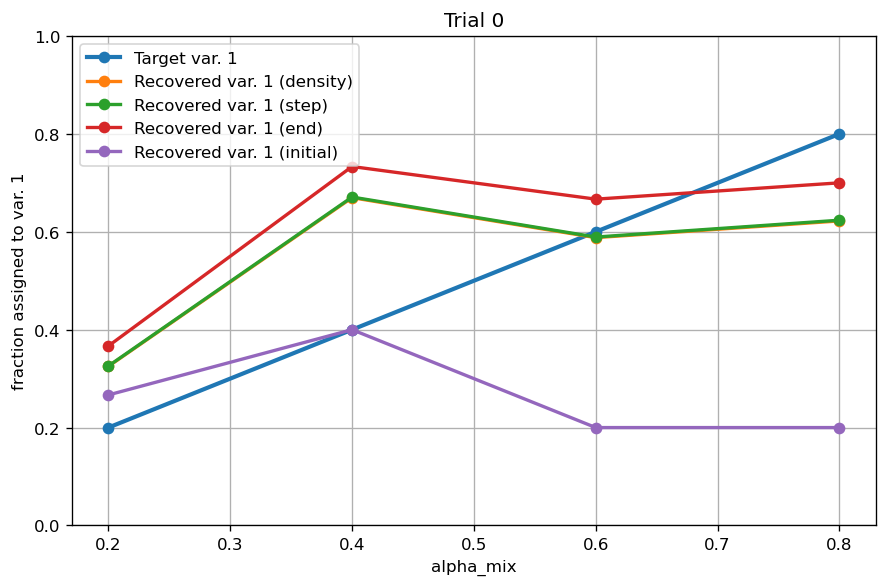

In [111]:
plot_trial_recovery(df_trial0_alpha, title="Trial 0")

# Do the search

In [133]:
from pathlib import Path
import json
import traceback
import multiprocessing as mp
from concurrent.futures import ProcessPoolExecutor, as_completed

OUTDIR = Path("/glade/derecho/scratch/jhayron/DataCaStLeBTs/ResultsSynthetic/multivariate_v0")
OUTDIR.mkdir(parents=True, exist_ok=True)

BUNDLES_DIR = OUTDIR / "bundles"
BUNDLES_DIR.mkdir(parents=True, exist_ok=True)

JOBS_JSONL = OUTDIR / "results_jobs.jsonl"          # one row per trial
ALPHAS_JSONL = OUTDIR / "results_alphas.jsonl"      # one row per trial x alpha_mix
MEMBERS_JSONL = OUTDIR / "results_members.jsonl"    # one row per member
META_JSON = OUTDIR / "run_metadata.json"
SUMMARY_JSON = OUTDIR / "run_summary.json"

JOBS_CSV = OUTDIR / "results_jobs_snapshot.csv"
ALPHAS_CSV = OUTDIR / "results_alphas_snapshot.csv"
MEMBERS_CSV = OUTDIR / "results_members_snapshot.csv"

print("Saving to:", OUTDIR.resolve())

Saving to: /glade/derecho/scratch/jhayron/DataCaStLeBTs/ResultsSynthetic/multivariate_v0


In [134]:
def append_jsonl(path: Path, records):
    if not records:
        return
    with path.open("a", encoding="utf-8") as f:
        for rec in records:
            f.write(json.dumps(rec, default=str) + "\n")
        f.flush()
        os.fsync(f.fileno())


def atomic_write_json(path: Path, obj):
    tmp = path.with_suffix(path.suffix + ".tmp")
    with tmp.open("w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2, default=str)
    tmp.replace(path)


def atomic_write_csv(path: Path, df: pd.DataFrame):
    tmp = path.with_suffix(path.suffix + ".tmp")
    df.to_csv(tmp, index=False)
    tmp.replace(path)


def load_jsonl_records(path: Path):
    if not path.exists():
        return []
    out = []
    with path.open("r", encoding="utf-8") as f:
        for i, line in enumerate(f, start=1):
            line = line.strip()
            if not line:
                continue
            try:
                out.append(json.loads(line))
            except Exception:
                print(f"Warning: could not parse line {i} in {path}")
    return out


def load_completed_trial_ids(path: Path):
    rows = load_jsonl_records(path)
    done = set()
    for r in rows:
        try:
            done.add(int(r["trial_id"]))
        except Exception:
            pass
    return done, rows

In [135]:
def evaluate_physical_validity(summary,
                               min_ok_frac=0.80,
                               min_q25_n_steps=20,
                               min_mean_net_displacement=8.0,
                               max_mean_stagnant_frac=0.75,
                               max_step_var2_frac=0.85,
                               max_density_var2_frac=0.85,
                               min_frac_members_any_nontrivial=0.50,
                               min_frac_members_end_nontrivial=0.50):
    vm = summary["validity_metrics"]

    checks = {
        "valid_ok_frac": bool(np.isfinite(vm["ok_frac"])) and (vm["ok_frac"] >= min_ok_frac),
        "valid_q25_n_steps": bool(np.isfinite(vm["q25_n_steps"])) and (vm["q25_n_steps"] >= min_q25_n_steps),
        "valid_mean_net_displacement": bool(np.isfinite(vm["mean_net_displacement"])) and (
            vm["mean_net_displacement"] >= min_mean_net_displacement
        ),
        "valid_mean_stagnant_frac": bool(np.isfinite(vm["mean_stagnant_frac"])) and (
            vm["mean_stagnant_frac"] <= max_mean_stagnant_frac
        ),
        "valid_step_var2_not_dominant": bool(np.isfinite(summary["step_parent_frac"][2])) and (
            summary["step_parent_frac"][2] <= max_step_var2_frac
        ),
        "valid_density_var2_not_dominant": bool(np.isfinite(summary["density_integral_frac"][2])) and (
            summary["density_integral_frac"][2] <= max_density_var2_frac
        ),
        "valid_any_nontrivial": bool(np.isfinite(vm["frac_members_any_nontrivial"])) and (
            vm["frac_members_any_nontrivial"] >= min_frac_members_any_nontrivial
        ),
        "valid_end_nontrivial": bool(np.isfinite(vm["frac_members_end_nontrivial"])) and (
            vm["frac_members_end_nontrivial"] >= min_frac_members_end_nontrivial
        ),
    }

    checks["is_valid_physical"] = all(checks.values())
    return checks

In [136]:
def _bundle_name(trial_id, alpha_mix):
    alpha_tag = str(alpha_mix).replace(".", "p")
    return f"trial_{trial_id:05d}_alpha_{alpha_tag}"


def serialize_ensemble_bundle(trial_id, alpha_mix, trial, case, params, ensemble_out, summary):
    members = ensemble_out["members"]
    M = len(members)

    lengths = np.array([len(np.asarray(m["parents"])) for m in members], dtype=np.int32)
    max_len = int(lengths.max()) if len(lengths) else 0

    centers_pad = np.full((M, max_len, 2), np.nan, dtype=np.float32)
    parents_pad = np.full((M, max_len), -1, dtype=np.int16)
    ok_arr = np.zeros(M, dtype=np.int8)
    elapsed_arr = np.full(M, np.nan, dtype=np.float32)
    member_id_arr = np.full(M, -1, dtype=np.int32)
    error_list = []

    for i, m in enumerate(members):
        member_id_arr[i] = int(m["member_id"])
        ok_arr[i] = int(bool(m["ok"]))
        elapsed_arr[i] = float(m.get("elapsed_sec", np.nan))
        error_list.append(str(m.get("error", "")))

        centers = np.asarray(m["centers"], dtype=float)
        parents = np.asarray(m["parents"], dtype=int)

        L = len(parents)
        if L > 0:
            centers_pad[i, :L, :] = centers.astype(np.float32)
            parents_pad[i, :L] = parents.astype(np.int16)

    density1 = summary["density_by_parent"][1].astype(np.float32)
    density2 = summary["density_by_parent"][2].astype(np.float32)
    density3 = summary["density_by_parent"][3].astype(np.float32)

    meta = {
        "trial_id": int(trial_id),
        "alpha_mix": float(alpha_mix),
        "trial": copy.deepcopy(trial),
        "params": copy.deepcopy(params),
        "case_meta": {
            "T": int(case["T"]),
            "N_inject": int(case["N_inject"]),
            "tau_mix": int(case["tau_mix"]),
            "event": [float(case["event"][0]), float(case["event"][1])],
            "target_parent_fractions": {
                "1": float(case["target_parent_fractions"][1]),
                "3": float(case["target_parent_fractions"][3]),
            },
        },
        "summary_small": {
            "n_members": int(summary["n_members"]),
            "n_ok": int(summary["n_ok"]),
            "initial_parent_counts": {str(k): int(v) for k, v in summary["initial_parent_counts"].items()},
            "end_parent_counts": {str(k): int(v) for k, v in summary["end_parent_counts"].items()},
            "step_parent_counts": {str(k): int(v) for k, v in summary["step_parent_counts"].items()},
            "initial_parent_frac": {str(k): float(v) for k, v in summary["initial_parent_frac"].items()},
            "end_parent_frac": {str(k): float(v) for k, v in summary["end_parent_frac"].items()},
            "step_parent_frac": {str(k): float(v) for k, v in summary["step_parent_frac"].items()},
            "density_integral": {str(k): float(v) for k, v in summary["density_integral"].items()},
            "density_integral_frac": {str(k): float(v) for k, v in summary["density_integral_frac"].items()},
            "validity_metrics": {k: float(v) if np.isscalar(v) and np.isfinite(v) else v
                                 for k, v in summary["validity_metrics"].items()},
        },
        "errors": error_list,
    }

    return {
        "meta": meta,
        "arrays": {
            "centers": centers_pad,
            "parents": parents_pad,
            "lengths": lengths,
            "ok": ok_arr,
            "elapsed_sec": elapsed_arr,
            "member_id": member_id_arr,
            "density_parent1": density1,
            "density_parent2": density2,
            "density_parent3": density3,
            "xs": np.asarray(case["xs"], dtype=np.float32),
            "ys": np.asarray(case["ys"], dtype=np.float32),
            "truth_centers_A": np.asarray(case["centers_A"], dtype=np.float32),
            "truth_centers_C": np.asarray(case["centers_C"], dtype=np.float32),
        }
    }


def save_ensemble_bundle(bundle, bundles_dir=BUNDLES_DIR):
    trial_id = int(bundle["meta"]["trial_id"])
    alpha_mix = float(bundle["meta"]["alpha_mix"])
    stem = _bundle_name(trial_id, alpha_mix)

    npz_path = bundles_dir / f"{stem}.npz"
    json_path = bundles_dir / f"{stem}.json"

    np.savez_compressed(npz_path, **bundle["arrays"])
    atomic_write_json(json_path, bundle["meta"])

    return npz_path, json_path

In [137]:
def evaluate_trial_across_alphas_full(trial_id, trial, alpha_grid=ALPHA_MIX_GRID, M=30, seed=123):
    params = build_params_from_trial_multivar(trial)

    rows_alpha = []
    rows_members = []
    bundles = []

    for j, alpha_mix in enumerate(alpha_grid):
        case = build_multivariate_case(
            alpha_mix=alpha_mix,
            T=40,
            N_inject=8,
            seed=GLOBAL_SEED,
        )

        ensemble_out = run_ensemble(
            case,
            params,
            M=M,
            seed=seed + 1000 * trial_id + j,
        )

        summary = summarize_ensemble(case, ensemble_out, params)
        validity = evaluate_physical_validity(summary)
        row = summarize_against_truth(case, summary).iloc[0].to_dict()

        row_alpha = {
            "trial_id": int(trial_id),
            **copy.deepcopy(trial),
            **row,
            **validity,
        }
        rows_alpha.append(row_alpha)

        dfm = summary["df_members"].copy()
        dfm["trial_id"] = int(trial_id)
        dfm["alpha_mix"] = float(alpha_mix)
        for k, v in trial.items():
            dfm[k] = v
        rows_members.extend(dfm.to_dict(orient="records"))

        bundles.append(serialize_ensemble_bundle(
            trial_id=trial_id,
            alpha_mix=alpha_mix,
            trial=trial,
            case=case,
            params=params,
            ensemble_out=ensemble_out,
            summary=summary,
        ))

    df_alpha = pd.DataFrame(rows_alpha).sort_values("alpha_mix").reset_index(drop=True)

    agg = {
        "trial_id": int(trial_id),
        **copy.deepcopy(trial),
        "n_alpha": int(len(df_alpha)),
        "n_alpha_valid_physical": int(df_alpha["is_valid_physical"].sum()),
        "frac_alpha_valid_physical": float(df_alpha["is_valid_physical"].mean()),

        "mean_mae_initial": float(df_alpha["mae_initial"].mean()),
        "mean_mae_end": float(df_alpha["mae_end"].mean()),
        "mean_mae_step": float(df_alpha["mae_step"].mean()),
        "mean_mae_density": float(df_alpha["mae_density"].mean()),

        "max_mae_initial": float(df_alpha["mae_initial"].max()),
        "max_mae_end": float(df_alpha["mae_end"].max()),
        "max_mae_step": float(df_alpha["mae_step"].max()),
        "max_mae_density": float(df_alpha["mae_density"].max()),

        "mean_ok_frac": float(df_alpha["ok_frac"].mean()),
        "min_ok_frac": float(df_alpha["ok_frac"].min()),
        "mean_mean_n_steps": float(df_alpha["mean_n_steps"].mean()),
        "min_q25_n_steps": float(df_alpha["q25_n_steps"].min()),
        "mean_mean_net_displacement": float(df_alpha["mean_net_displacement"].mean()),
        "mean_mean_path_length": float(df_alpha["mean_path_length"].mean()),
        "mean_mean_stagnant_frac": float(df_alpha["mean_stagnant_frac"].mean()),

        "mean_density_var2_frac": float(df_alpha["density_frac_var2"].mean()),
        "mean_step_var2_frac": float(df_alpha["step_frac_var2"].mean()),
        "mean_initial_var2_frac": float(df_alpha["initial_frac_var2"].mean()),
        "mean_end_var2_frac": float(df_alpha["end_frac_var2"].mean()),

        "corr_alpha_vs_density_var1": _safe_corr(df_alpha["target_var1"], df_alpha["density_frac_var1"]),
        "corr_alpha_vs_step_var1": _safe_corr(df_alpha["target_var1"], df_alpha["step_frac_var1"]),
        "corr_alpha_vs_end_var1": _safe_corr(df_alpha["target_var1"], df_alpha["end_frac_var1"]),
        "corr_alpha_vs_initial_var1": _safe_corr(df_alpha["target_var1"], df_alpha["initial_frac_var1"]),
    }

    return {
        "trial_row": agg,
        "alpha_rows": rows_alpha,
        "member_rows": rows_members,
        "bundles": bundles,
    }

In [138]:
def build_multivar_jobs(n_trials, seed=11):
    rng = np.random.default_rng(seed)
    jobs = []
    for trial_id in range(n_trials):
        jobs.append((trial_id, sample_multivar_trial(rng)))
    return jobs

In [139]:
def evaluate_trial_worker(job, alpha_grid=ALPHA_MIX_GRID, M=30, seed=11):
    trial_id, trial = job
    t0 = time.perf_counter()

    # try:
    out = evaluate_trial_across_alphas_full(
        trial_id=trial_id,
        trial=trial,
        alpha_grid=alpha_grid,
        M=M,
        seed=seed,
    )

    trial_row = out["trial_row"]
    trial_row["elapsed_sec"] = float(time.perf_counter() - t0)
    trial_row["ok"] = 1
    trial_row["error"] = ""

    return {
        "ok": True,
        "trial_row": trial_row,
        "alpha_rows": out["alpha_rows"],
        "member_rows": out["member_rows"],
        "bundles": out["bundles"],
    }

    # except Exception as e:
    #     err = "".join(traceback.format_exception_only(type(e), e)).strip()
    #     trial_row = {
    #         "trial_id": int(trial_id),
    #         **copy.deepcopy(trial),
    
    #         "n_alpha": np.nan,
    #         "n_alpha_valid_physical": np.nan,
    #         "frac_alpha_valid_physical": np.nan,
    
    #         "mean_mae_initial": np.nan,
    #         "mean_mae_end": np.nan,
    #         "mean_mae_step": np.nan,
    #         "mean_mae_density": np.nan,
    
    #         "max_mae_initial": np.nan,
    #         "max_mae_end": np.nan,
    #         "max_mae_step": np.nan,
    #         "max_mae_density": np.nan,
    
    #         "mean_ok_frac": np.nan,
    #         "min_ok_frac": np.nan,
    #         "mean_mean_n_steps": np.nan,
    #         "min_q25_n_steps": np.nan,
    #         "mean_mean_net_displacement": np.nan,
    #         "mean_mean_path_length": np.nan,
    #         "mean_mean_stagnant_frac": np.nan,
    
    #         "mean_density_var2_frac": np.nan,
    #         "mean_step_var2_frac": np.nan,
    #         "mean_initial_var2_frac": np.nan,
    #         "mean_end_var2_frac": np.nan,
    
    #         "corr_alpha_vs_density_var1": np.nan,
    #         "corr_alpha_vs_step_var1": np.nan,
    #         "corr_alpha_vs_end_var1": np.nan,
    #         "corr_alpha_vs_initial_var1": np.nan,
    
    #         "elapsed_sec": float(time.perf_counter() - t0),
    #         "ok": 0,
    #         "error": err,
    #     }
    
    #     return {
    #         "ok": False,
    #         "trial_row": trial_row,
    #         "alpha_rows": [],
    #         "member_rows": [],
    #         "bundles": [],
    #     }

In [140]:
def run_multivar_search_parallel(
    outdir=OUTDIR,
    n_trials=40,
    n_workers=8,
    M=30,
    alpha_grid=ALPHA_MIX_GRID,
    seed=11,
    flush_every=2,
):
    outdir = Path(outdir)
    outdir.mkdir(parents=True, exist_ok=True)

    all_jobs = build_multivar_jobs(n_trials=n_trials, seed=seed)
    completed_trial_ids, existing_trial_rows = load_completed_trial_ids(JOBS_JSONL)
    pending_jobs = [job for job in all_jobs if int(job[0]) not in completed_trial_ids]

    meta = {
        "seed": int(seed),
        "n_trials": int(n_trials),
        "n_workers": int(n_workers),
        "M": int(M),
        "alpha_grid": [float(x) for x in alpha_grid],
        "flush_every": int(flush_every),
        "n_completed_found_at_start": int(len(completed_trial_ids)),
        "n_pending_at_start": int(len(pending_jobs)),
        "outdir": str(outdir.resolve()),
        "updated_at": pd.Timestamp.utcnow().isoformat(),
    }
    atomic_write_json(META_JSON, meta)

    print(f"Total trials: {len(all_jobs)}")
    print(f"Completed:    {len(completed_trial_ids)}")
    print(f"Pending:      {len(pending_jobs)}")

    if len(pending_jobs) == 0:
        print("Nothing to do.")
        return

    buf_trials = []
    buf_alphas = []
    buf_members = []

    t0 = time.perf_counter()
    n_done_this_run = 0

    ctx = mp.get_context("fork")

    with ProcessPoolExecutor(max_workers=n_workers, mp_context=ctx) as ex:
        futures = [ex.submit(evaluate_trial_worker, job, alpha_grid, M, seed) for job in pending_jobs]

        for fut in as_completed(futures):
            result = fut.result()

            trial_row = result["trial_row"]
            alpha_rows = result["alpha_rows"]
            member_rows = result["member_rows"]
            bundles = result["bundles"]

            for bundle in bundles:
                npz_path, json_path = save_ensemble_bundle(bundle, bundles_dir=BUNDLES_DIR)

                trial_id = int(bundle["meta"]["trial_id"])
                alpha_mix = float(bundle["meta"]["alpha_mix"])

                for row in alpha_rows:
                    if int(row["trial_id"]) == trial_id and float(row["alpha_mix"]) == alpha_mix:
                        row["bundle_npz"] = str(npz_path)
                        row["bundle_json"] = str(json_path)

                for row in member_rows:
                    if int(row["trial_id"]) == trial_id and float(row["alpha_mix"]) == alpha_mix:
                        row["bundle_npz"] = str(npz_path)
                        row["bundle_json"] = str(json_path)

            buf_trials.append(trial_row)
            buf_alphas.extend(alpha_rows)
            buf_members.extend(member_rows)

            n_done_this_run += 1

            if (n_done_this_run % flush_every == 0) or (n_done_this_run == len(pending_jobs)):
                append_jsonl(JOBS_JSONL, buf_trials)
                append_jsonl(ALPHAS_JSONL, buf_alphas)
                append_jsonl(MEMBERS_JSONL, buf_members)

                jobs_now = pd.DataFrame(load_jsonl_records(JOBS_JSONL))
                alphas_now = pd.DataFrame(load_jsonl_records(ALPHAS_JSONL))
                members_now = pd.DataFrame(load_jsonl_records(MEMBERS_JSONL))

                if len(jobs_now):
                    atomic_write_csv(JOBS_CSV, jobs_now)
                if len(alphas_now):
                    atomic_write_csv(ALPHAS_CSV, alphas_now)
                if len(members_now):
                    atomic_write_csv(MEMBERS_CSV, members_now)

                elapsed = time.perf_counter() - t0
                rate = n_done_this_run / elapsed if elapsed > 0 else np.nan

                ok_total = int(jobs_now["ok"].sum()) if len(jobs_now) else 0
                valid_total = int(jobs_now.get("n_alpha_valid_physical", pd.Series(dtype=float)).sum()) if len(jobs_now) else 0
                best_msg = "best=NA"
                if len(jobs_now) and ("mean_mae_density" in jobs_now.columns):
                    good = jobs_now[jobs_now.get("ok", 0) == 1].copy()
                    good = good[good["mean_mae_density"].notna()]
                
                    if len(good):
                        sort_cols = [c for c in ["frac_alpha_valid_physical", "mean_mae_density", "mean_mae_step"] if c in good.columns]
                        ascending = []
                        for c in sort_cols:
                            if c == "frac_alpha_valid_physical":
                                ascending.append(False)
                            else:
                                ascending.append(True)
                
                        good = good.sort_values(sort_cols, ascending=ascending)
                        best = good.iloc[0]
                
                        valid_frac_txt = (
                            f"{best['frac_alpha_valid_physical']:.2f}"
                            if "frac_alpha_valid_physical" in good.columns and pd.notna(best["frac_alpha_valid_physical"])
                            else "NA"
                        )
                
                        best_msg = (
                            f"best_trial={int(best['trial_id'])} "
                            f"valid_frac={valid_frac_txt} "
                            f"mean_mae_density={best['mean_mae_density']:.4f}"
                        )

                print(
                    f"[{n_done_this_run:4d}/{len(pending_jobs)}] "
                    f"ok_total={ok_total:4d} "
                    f"valid_alpha_total={valid_total:4d} "
                    f"rate={rate:.2f} trials/s "
                    f"{best_msg}",
                    flush=True,
                )

                buf_trials = []
                buf_alphas = []
                buf_members = []

    jobs_final = pd.DataFrame(load_jsonl_records(JOBS_JSONL))
    alphas_final = pd.DataFrame(load_jsonl_records(ALPHAS_JSONL))
    members_final = pd.DataFrame(load_jsonl_records(MEMBERS_JSONL))

    if len(jobs_final):
        sort_cols = [c for c in ["ok", "frac_alpha_valid_physical", "mean_mae_density", "mean_mae_step"] if c in jobs_final.columns]
        ascending = []
        for c in sort_cols:
            if c in ["ok", "frac_alpha_valid_physical"]:
                ascending.append(False)
            else:
                ascending.append(True)
    
        jobs_sorted = jobs_final.sort_values(sort_cols, ascending=ascending)
        atomic_write_csv(outdir / "results_jobs_final.csv", jobs_sorted)

    if len(alphas_final):
        atomic_write_csv(outdir / "results_alphas_final.csv", alphas_final)

    if len(members_final):
        atomic_write_csv(outdir / "results_members_final.csv", members_final)

    summary = {
        "finished_at": pd.Timestamp.utcnow().isoformat(),
        "elapsed_sec": float(time.perf_counter() - t0),
        "n_trials_total": int(n_trials),
        "n_trials_completed_this_run": int(n_done_this_run),
        "n_trials_ok_total": int(jobs_final["ok"].sum()) if len(jobs_final) else 0,
        "n_trials_failed_total": int((1 - jobs_final["ok"]).sum()) if len(jobs_final) else 0,
        "n_alpha_rows_total": int(len(alphas_final)),
        "n_member_rows_total": int(len(members_final)),
    }
    atomic_write_json(SUMMARY_JSON, summary)

    return jobs_final, alphas_final, members_final

In [141]:
jobs_df, alphas_df, members_df = run_multivar_search_parallel(
    outdir=OUTDIR,
    n_trials=8,      # good first real debug batch
    n_workers=8,
    M=20,
    alpha_grid=ALPHA_MIX_GRID,
    seed=11,
    flush_every=2,
)

Total trials: 8
Completed:    0
Pending:      8
[   2/8] ok_total=   2 valid_alpha_total=   8 rate=0.01 trials/s best_trial=0 valid_frac=1.00 mean_mae_density=0.1433
[   4/8] ok_total=   4 valid_alpha_total=  16 rate=0.01 trials/s best_trial=0 valid_frac=1.00 mean_mae_density=0.1433
[   6/8] ok_total=   6 valid_alpha_total=  23 rate=0.01 trials/s best_trial=0 valid_frac=1.00 mean_mae_density=0.1433
[   8/8] ok_total=   8 valid_alpha_total=  31 rate=0.01 trials/s best_trial=0 valid_frac=1.00 mean_mae_density=0.1433
